In [1]:
import numpy as np

data_onehot = np.load("../data/onehot_preds_and_targets_CE_weight.npz")
data_embedding = np.load("../data/emb_preds_and_targets_CE_weight.npz")
p_emb = data_embedding["preds"]
y_emb = data_embedding["targets"]
p_onehot = data_onehot["preds"]
y_onehot = data_onehot["targets"]



In [2]:

def stratified_random_baseline(y_true, seed=42):
    """
    Create a stratified random baseline: samples class labels randomly
    according to their true class distribution.

    Parameters:
        y_true (np.ndarray): Ground truth labels
        seed (int): Random seed

    Returns:
        y_pred (np.ndarray): Random predictions drawn from class distribution
    """
    np.random.seed(seed)
    unique, counts = np.unique(y_true, return_counts=True)
    probs = counts / counts.sum()
    return np.random.choice(unique, size=len(y_true), p=probs)

# ➕ Use it to get your baseline
p_base = stratified_random_baseline(y_emb)
y_base = y_emb.copy()  # Same targets as embedding model


In [3]:
from sklearn.metrics import f1_score
from tqdm import trange

all_labels = np.unique(np.concatenate([y_emb, y_onehot, y_base]))
n_bootstrap = 500
num_classes = len(all_labels)

f1s_boot_embedding = np.zeros((n_bootstrap, num_classes))
f1s_boot_onehot = np.zeros((n_bootstrap, num_classes))
f1s_boot_baseline = np.zeros((n_bootstrap, num_classes))

for i in trange(n_bootstrap, desc="Bootstrapping"):
    idx_emb = np.random.choice(len(y_emb), size=len(y_emb), replace=True)
    idx_onehot = np.random.choice(len(y_onehot), size=len(y_onehot), replace=True)
    idx_base = np.random.choice(len(y_base), size=len(y_base), replace=True)

    f1s_boot_embedding[i] = f1_score(y_emb[idx_emb], p_emb[idx_emb], average=None, labels=all_labels, zero_division=0)
    f1s_boot_onehot[i] = f1_score(y_onehot[idx_onehot], p_onehot[idx_onehot], average=None, labels=all_labels, zero_division=0)
    f1s_boot_baseline[i] = f1_score(y_base[idx_base], p_base[idx_base], average=None, labels=all_labels, zero_division=0)

def mean_ci(array, ci=95):
    lower = (100 - ci) / 2
    upper = 100 - lower
    return np.nanmean(array, axis=0), np.nanpercentile(array, lower, axis=0), np.nanpercentile(array, upper, axis=0)

mean_f1_emb, low_f1_emb, high_f1_emb = mean_ci(f1s_boot_embedding)
mean_f1_onehot, low_f1_onehot, high_f1_onehot = mean_ci(f1s_boot_onehot)
mean_f1_base, low_f1_base, high_f1_base = mean_ci(f1s_boot_baseline)

# === Print mean ± CI per model ===
print("\n=== Bootstrap Summary (Per-Class F1 Mean ± CI) ===")

mean_ci_error_emb = np.nanmean((high_f1_emb - low_f1_emb) / 2)
print(f"Embedding : {np.nanmean(mean_f1_emb):.4f} ± {mean_ci_error_emb:.4f} "
      f"(95% CI: [{np.nanmean(low_f1_emb):.4f}, {np.nanmean(high_f1_emb):.4f}])")

mean_ci_error_onehot = np.nanmean((high_f1_onehot - low_f1_onehot) / 2)
print(f"One-Hot   : {np.nanmean(mean_f1_onehot):.4f} ± {mean_ci_error_onehot:.4f} "
      f"(95% CI: [{np.nanmean(low_f1_onehot):.4f}, {np.nanmean(high_f1_onehot):.4f}])")

mean_ci_error_base = np.nanmean((high_f1_base - low_f1_base) / 2)
print(f"Baseline  : {np.nanmean(mean_f1_base):.4f} ± {mean_ci_error_base:.4f} "
      f"(95% CI: [{np.nanmean(low_f1_base):.4f}, {np.nanmean(high_f1_base):.4f}])")


Bootstrapping: 100%|██████████| 500/500 [23:33<00:00,  2.83s/it]


=== Bootstrap Summary (Per-Class F1 Mean ± CI) ===
Embedding : 0.7257 ± 0.0063 (95% CI: [0.7193, 0.7319])
One-Hot   : 0.3063 ± 0.0110 (95% CI: [0.2953, 0.3173])
Baseline  : 0.0186 ± 0.0007 (95% CI: [0.0180, 0.0193])


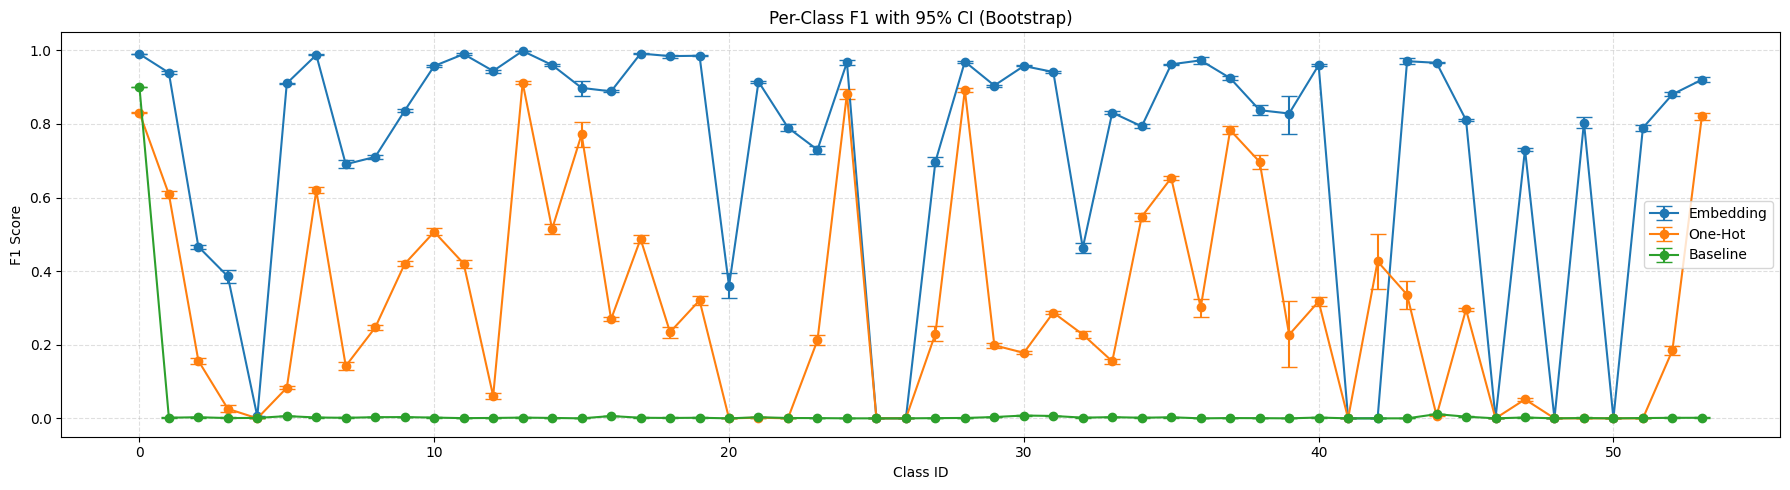

In [4]:
import matplotlib.pyplot as plt

x = np.arange(num_classes)
plt.figure(figsize=(18, 5))

plt.errorbar(x, mean_f1_emb, yerr=[mean_f1_emb - low_f1_emb, high_f1_emb - mean_f1_emb], label="Embedding", fmt='-o', capsize=6)
plt.errorbar(x, mean_f1_onehot, yerr=[mean_f1_onehot - low_f1_onehot, high_f1_onehot - mean_f1_onehot], label="One-Hot", fmt='-o', capsize=6)
plt.errorbar(x, mean_f1_base, yerr=[mean_f1_base - low_f1_base, high_f1_base - mean_f1_base], label="Baseline", fmt='-o', capsize=6)

plt.xlabel("Class ID")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 with 95% CI (Bootstrap)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("per_class_boot.png", dpi=1000)
plt.show()


In [5]:
from sklearn.metrics import matthews_corrcoef, f1_score

def bootstrap_metrics(y_true, y_pred, metric_fns, n_bootstrap=500):
    results = {name: [] for name in metric_fns}
    for _ in trange(n_bootstrap, leave=False):
        idx = np.random.choice(len(y_true), len(y_true), replace=True)
        y_sample = y_true[idx]
        p_sample = y_pred[idx]
        for name, fn in metric_fns.items():
            try:
                score = fn(y_sample, p_sample)
            except:
                score = np.nan
            results[name].append(score)
    summary = {
        name: (
            np.nanmean(vals),
            np.nanpercentile(vals, 2.5),
            np.nanpercentile(vals, 97.5)
        )
        for name, vals in results.items()
    }
    return summary, results

metric_fns = {
    "Weighted F1": lambda y, p: f1_score(y, p, average="macro", zero_division=0),
    "MCC": matthews_corrcoef
}

results_emb, scores_emb = bootstrap_metrics(y_emb, p_emb, metric_fns)
results_one, scores_one = bootstrap_metrics(y_onehot, p_onehot, metric_fns)
results_base, scores_base = bootstrap_metrics(y_base, p_base, metric_fns)

# === Print results ===
print("\n=== Bootstrap Summary (Overall Metrics ± CI) ===")
for name, result in zip(["Embedding", "One-Hot", "Baseline"],
                        [results_emb, results_one, results_base]):
    print(f"\n--- {name} ---")
    for metric in metric_fns:
        mean, low, high = result[metric]
        print(f"{metric:12s}: {mean:.4f} ± {high - mean:.4f} (95% CI: [{low:.4f}, {high:.4f}])")



=== Bootstrap Summary (Overall Metrics ± CI) ===

--- Embedding ---
Weighted F1 : 0.6998 ± 0.0015 (95% CI: [0.6984, 0.7013])
MCC         : 0.8838 ± 0.0006 (95% CI: [0.8832, 0.8844])

--- One-Hot ---
Weighted F1 : 0.2953 ± 0.0025 (95% CI: [0.2928, 0.2978])
MCC         : 0.3504 ± 0.0014 (95% CI: [0.3491, 0.3518])

--- Baseline ---
Weighted F1 : 0.0185 ± 0.0001 (95% CI: [0.0184, 0.0186])
MCC         : -0.0002 ± 0.0004 (95% CI: [-0.0006, 0.0003])


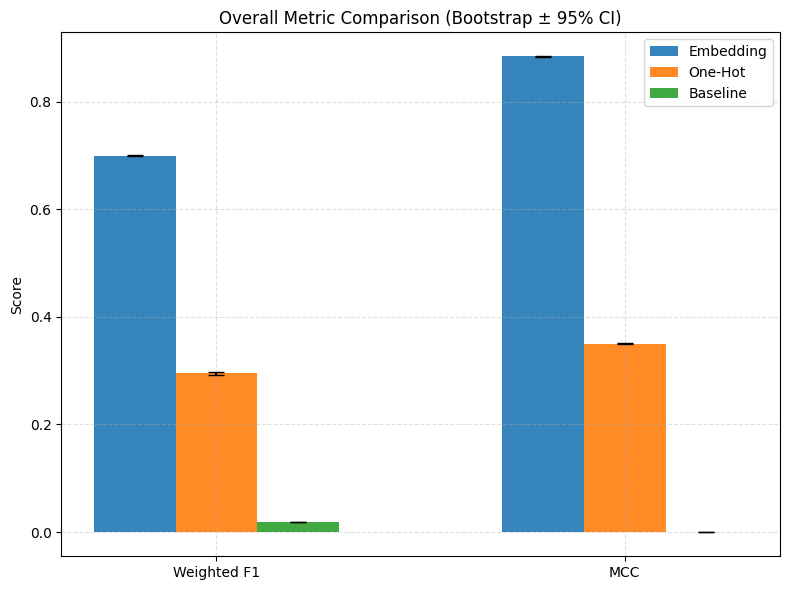

In [6]:
models = ["Embedding", "One-Hot", "Baseline"]
metrics = list(metric_fns.keys())

scores = []
errors_lower = []
errors_upper = []

for metric in metrics:
    row = []
    lo = []
    hi = []
    for res in [results_emb, results_one, results_base]:
        mean, low, high = res[metric]
        row.append(mean)
        lo.append(mean - low)
        hi.append(high - mean)
    scores.append(row)
    errors_lower.append(lo)
    errors_upper.append(hi)

x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 6))
for i, model in enumerate(models):
    ax.bar(x + (i - 1) * width,
           [scores[j][i] for j in range(len(metrics))],
           width,
           yerr=[[errors_lower[j][i] for j in range(len(metrics))],
                 [errors_upper[j][i] for j in range(len(metrics))]],
           capsize=6,
           label=model,
           alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Overall Metric Comparison (Bootstrap ± 95% CI)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("overall_boot.png", dpi=1000)
plt.show()
